# TimeGPT ile Commodity Fiyat Tahmini

Zaman serisi tahmininde, test seti gelecekteki verileri temsil eder.
Model, test setinin ilk gününü tahmin ederken train + validation verilerini kullanır.
Sonraki günlerde, bir önceki test gününün gerçek değeri de modele eklenir.


In [ ]:
import os
import numpy as np
import pandas as pd
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Güvenli MAPE ---
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Tek günlük kaydırmalı tahmin (expanding window) ---
def rolling_1d_forecast(nixtla_client, train_df, eval_df, finetune_steps, level, freq="D"):
    """
    train_df: sadece 'ds','y' (train veya train+val)
    eval_df : üzerinde kaydırmalı tahmin yapılacak set (val veya test)
    """
    current_train = train_df.copy()
    rows = []
    total = len(eval_df)

    for i in range(total):
        # İlerleme göstergesi: Her 50 günde bir veya ilk/son günde
        if i == 0 or (i + 1) % 50 == 0 or i == total - 1:
            print(f"  └─ İlerleme: {i+1}/{total} gün tamamlandı ({100*(i+1)/total:.1f}%)")
        
        # 1 gün ileri tahmin
        fcst = nixtla_client.forecast(
            df=current_train,
            h=1,
            time_col="ds",
            target_col="y",
            freq=freq,
            finetune_steps=finetune_steps,
            level=level  
        )
        pred = float(fcst["TimeGPT"].iloc[0])
        d    = eval_df["ds"].iloc[i]
        act  = float(eval_df["y"].iloc[i])

        rows.append({"ds": d, "y_true": act, "y_pred": pred})

        # Expanding window: gerçek değeri ekle
        current_train = pd.concat([current_train, pd.DataFrame({"ds":[d], "y":[act]})],
                                  ignore_index=True)

    res = pd.DataFrame(rows)
    res["abs_err"] = np.abs(res["y_true"] - res["y_pred"])
    return res

def eval_metrics(df):
    mae  = mean_absolute_error(df["y_true"], df["y_pred"])
    rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_pred"]))
    mape = safe_mape(df["y_true"].values, df["y_pred"].values)
    return dict(MAE=mae, RMSE=rmse, MAPE=mape)


In [14]:
# API anahtarı (ortam değişkeni)
TIMEGPT_API_KEY = "nixak-oY2tk5n200Iw4C2kRvZa8gMxHtbsmlCbOoTsBExuGX2MIAC1ej2mlGVVAQMHjZXUe5w6l0d4uO6tAVfV"
nixtla_client = NixtlaClient(api_key=TIMEGPT_API_KEY)

# 1) Veri yükle
raw = (pd.read_csv("commodity_features.csv")
         .rename(columns={"date":"ds", "CO1 Comdty":"y"}))
raw["ds"] = pd.to_datetime(raw["ds"], errors="coerce").dt.tz_localize(None)
raw["y"]  = pd.to_numeric(raw["y"], errors="coerce")

# Temel temizlik (global, sızıntı yok; sadece drop & sort)
base = (raw.dropna(subset=["ds","y"])
            .drop_duplicates(subset=["ds"])
            .sort_values("ds")
            .reset_index(drop=True))

# 2) 80-10-10 split
N = len(base)
n_tr = int(N*0.80)
n_va = int(N*0.10)

train_df = base.iloc[:n_tr].copy()
val_df   = base.iloc[n_tr:n_tr+n_va].copy()
test_df  = base.iloc[n_tr+n_va:].copy()

# 3) Her parçayı KENDİ İÇİNDE günlük düzenli hale getir (gap doldurma split sonrası)
def make_regular_daily(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    full = pd.DataFrame({"ds": pd.date_range(df["ds"].min(), df["ds"].max(), freq="D")})
    out = full.merge(df[["ds","y"]], on="ds", how="left")
    # Geleceğe bakmadan doldurma: ffill (başta boş kalırsa bfill)
    out["y"] = out["y"].ffill().bfill()
    return out

train_df = make_regular_daily(train_df)
val_df   = make_regular_daily(val_df)
test_df  = make_regular_daily(test_df)

# Sıra ve karışmama garantisi
assert train_df["ds"].max() < val_df["ds"].min(), "Train sonrası Val başlamalı!"
assert val_df["ds"].max()   < test_df["ds"].min(), "Val sonrası Test başlamalı!"

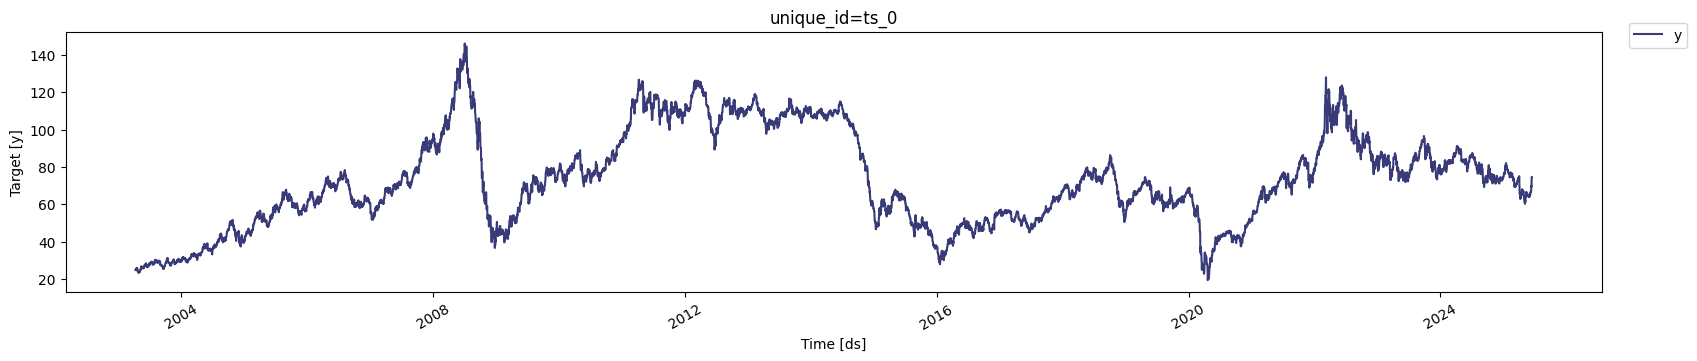

In [15]:
# Commodity fiyat serisini Nixtla ile çizdir
nixtla_client.plot(base, time_col="ds", target_col="y")

In [16]:
FINETUNE_CANDIDATES = [250]  # Sadece 250 ile test
LEVEL = [90]                              
FREQ  = "D"

val_scores = {}
for steps in FINETUNE_CANDIDATES:
    print(f"\n{'='*60}")
    print(f"Başladı: finetune_steps={steps}")
    print(f"Validation setinde {len(val_df)} gün var, her biri için tahmin yapılacak...")
    print(f"{'='*60}\n")
    
    val_roll = rolling_1d_forecast(
        nixtla_client=nixtla_client,
        train_df=train_df,      
        eval_df=val_df,         # val'i 1-gün kaydırarak dolaş
        finetune_steps=steps,
        level=LEVEL,
        freq=FREQ
    )
    
    val_scores[steps] = eval_metrics(val_roll)
    m = val_scores[steps]
    
    print(f"\n{'='*60}")
    print(f"✓ Bitti: finetune_steps={steps}")
    print(f"  MAE  = {m['MAE']:.4f}")
    print(f"  RMSE = {m['RMSE']:.4f}")
    print(f"  MAPE = {m['MAPE']:.2f}%")
    print(f"{'='*60}\n")

# En düşük MAPE'yi seç
best_steps = min(val_scores, key=lambda k: val_scores[k]["MAPE"])
print("\nValidation (rolling-1d) sonuçları:")
for s, m in val_scores.items():
    print(f"steps={s}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  MAPE={m['MAPE']:.2f}%")
print(f"\n>>> En iyi finetune_steps: {best_steps} (MAPE={val_scores[best_steps]['MAPE']:.2f}%)")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...



Başladı: finetune_steps=250
Validation setinde 810 gün var, her biri için tahmin yapılacak...

  └─ İlerleme: 1/810 gün tamamlandı (0.1%)


INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixt

  └─ İlerleme: 50/810 gün tamamlandı (6.2%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtl

...

  └─ İlerleme: 750/810 gün tamamlandı (92.6%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtl

  └─ İlerleme: 800/810 gün tamamlandı (98.8%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtl

  └─ İlerleme: 810/810 gün tamamlandı (100.0%)

✓ Bitti: finetune_steps=250
  MAE  = 1.2149
  RMSE = 2.0188
  MAPE = 1.38%


Validation (rolling-1d) sonuçları:
steps=250: MAE=1.2149  RMSE=2.0188  MAPE=1.38%

>>> En iyi finetune_steps: 250 (MAPE=1.38%)

✓ Bitti: finetune_steps=250
  MAE  = 1.2149
  RMSE = 2.0188
  MAPE = 1.38%


Validation (rolling-1d) sonuçları:
steps=250: MAE=1.2149  RMSE=2.0188  MAPE=1.38%

>>> En iyi finetune_steps: 250 (MAPE=1.38%)


In [ ]:
# Final eğitim seti = train + val (zaman sırasına göre)
train_val = pd.concat([train_df, val_df], ignore_index=True).sort_values("ds").reset_index(drop=True)

# --- CHECKPOINT SİSTEMİ İLE TEST ---
import os
import time

checkpoint_file = "test_checkpoint.csv"
start_from = 0

# Eğer checkpoint dosyası varsa, kaldığı yerden devam et
if os.path.exists(checkpoint_file):
    checkpoint_df = pd.read_csv(checkpoint_file)
    checkpoint_df["ds"] = pd.to_datetime(checkpoint_df["ds"])
    start_from = len(checkpoint_df)
    print(f"📂 Checkpoint bulundu! {start_from} gün tamamlanmış, kaldığı yerden devam ediliyor...")
    current_train = train_val.copy() # Eğitim setini baştan al
    # Checkpoint'teki verileri eğitim setine ekle
    for idx in range(start_from):
        d = test_df["ds"].iloc[idx]
        act = float(test_df["y"].iloc[idx])
        current_train = pd.concat([current_train, pd.DataFrame({"ds":[d], "y":[act]})], ignore_index=True) 
    rows = checkpoint_df.to_dict('records')
else:
    print("🆕 Yeni başlangıç yapılıyor...")
    current_train = train_val.copy()
    rows = []

total = len(test_df)
print(f"Test setinde toplam {total} gün var, {total - start_from} gün kaldı...\n")

# Rolling forecast loop
for i in range(start_from, total):
    # İlerleme göstergesi
    if i == start_from or (i + 1) % 50 == 0 or i == total - 1:
        print(f"  └─ İlerleme: {i+1}/{total} gün tamamlandı ({100*(i+1)/total:.1f}%)")
    
    try:
        # 1 gün ileri tahmin
        fcst = nixtla_client.forecast(
            df=current_train,
            h=1,
            time_col="ds",
            target_col="y",
            freq=FREQ,
            finetune_steps=best_steps,
            level=LEVEL
        )
        pred = float(fcst["TimeGPT"].iloc[0])
        d = test_df["ds"].iloc[i]
        act = float(test_df["y"].iloc[i])
        
        rows.append({"ds": d, "y_true": act, "y_pred": pred})
        
        # Expanding window: gerçek değeri ekle
        current_train = pd.concat([current_train, pd.DataFrame({"ds":[d], "y":[act]})], ignore_index=True)
        
        # Her 50 günde bir checkpoint kaydet
        if (i + 1) % 50 == 0:
            pd.DataFrame(rows).to_csv(checkpoint_file, index=False)
            print(f"    💾 Checkpoint kaydedildi: {i+1} gün")
    
    except Exception as e:
        print(f"\n⚠️ HATA (gün {i+1}): {e}")
        print(f"💾 Checkpoint kaydediliyor ve durduruluyor...")
        pd.DataFrame(rows).to_csv(checkpoint_file, index=False)
        print(f"✅ {len(rows)} gün kaydedildi. Daha sonra kaldığı yerden devam edebilirsiniz.")
        raise

# Son checkpoint kaydet
pd.DataFrame(rows).to_csv(checkpoint_file, index=False)
print(f"\n✅ Tamamlandı! Checkpoint dosyası güncellendi.\n")

# Sonuçları hesapla
test_roll = pd.DataFrame(rows)
test_roll["abs_err"] = np.abs(test_roll["y_true"] - test_roll["y_pred"])

test_metrics = eval_metrics(test_roll)
print("\nTEST (rolling-1d) metrikleri:")
print(f"MAE = {test_metrics['MAE']:.4f}")
print(f"RMSE= {test_metrics['RMSE']:.4f}")
print(f"MAPE= {test_metrics['MAPE']:.2f}%")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


📂 Checkpoint bulundu! 804 gün tamamlanmış, kaldığı yerden devam ediliyor...
Test setinde toplam 811 gün var, 7 gün kaldı...

  └─ İlerleme: 805/811 gün tamamlandı (99.3%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtl

  └─ İlerleme: 811/811 gün tamamlandı (100.0%)

✅ Tamamlandı! Checkpoint dosyası güncellendi.


TEST (rolling-1d) metrikleri:
MAE = 0.8194
RMSE= 1.2250
MAPE= 1.05%

✅ Tamamlandı! Checkpoint dosyası güncellendi.


TEST (rolling-1d) metrikleri:
MAE = 0.8194
RMSE= 1.2250
MAPE= 1.05%


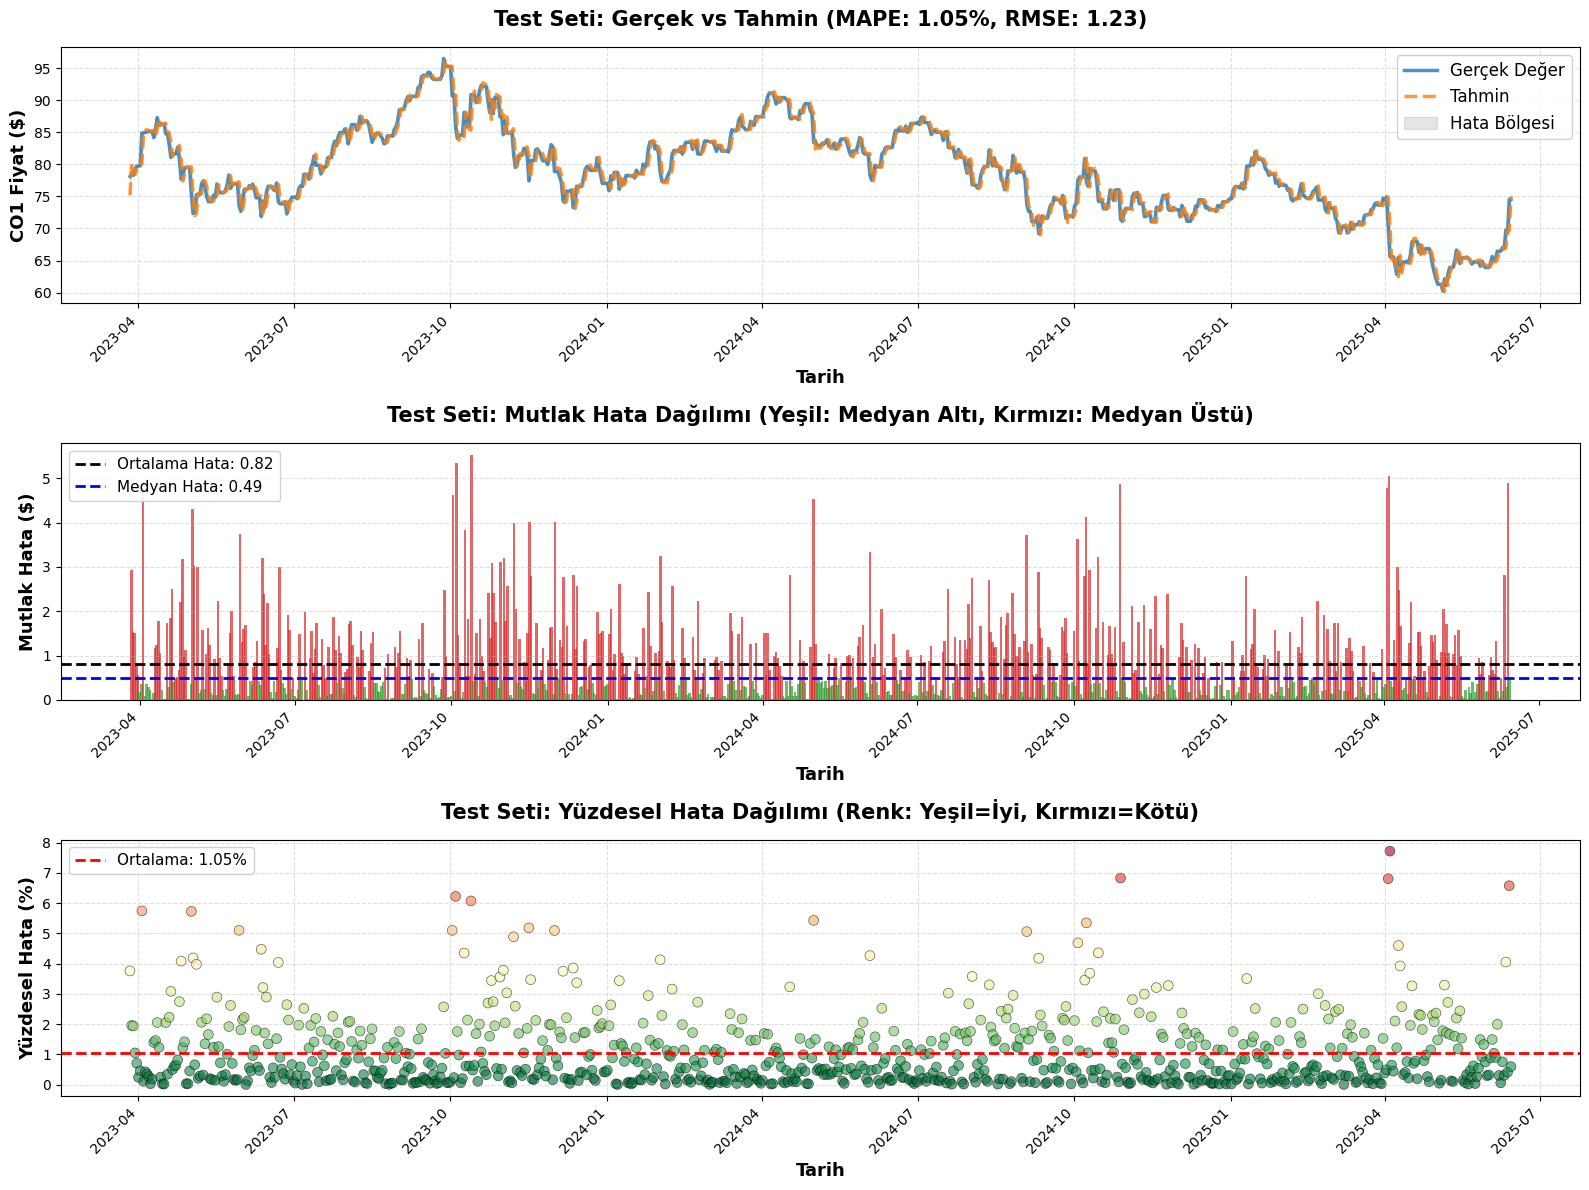


📊 DETAYLI TEST İSTATİSTİKLERİ
Toplam Gün Sayısı    : 811
Tarih Aralığı        : 2023-03-27 → 2025-06-14

--- Performans Metrikleri ---
MAE                  : 0.8194 $
RMSE                 : 1.2250 $
MAPE                 : 1.05 %

--- Hata Dağılımı ---
Min Mutlak Hata      : 0.0004 $
Max Mutlak Hata      : 5.5164 $
Ortalama Hata        : 0.8194 $
Medyan Hata          : 0.4915 $
Std Sapma (Hata)     : 0.9113 $

--- Fiyat İstatistikleri ---
Gerçek Fiyat (Ort)   : 78.81 $
Tahmin Fiyat (Ort)   : 78.86 $
Gerçek Fiyat (Min)   : 60.23 $
Gerçek Fiyat (Max)   : 96.55 $


In [29]:
# Test sonuçlarını görselleştir
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 3 grafik yan yana
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Gerçek vs Tahmin
ax1 = axes[0]
ax1.plot(test_roll["ds"], test_roll["y_true"], 
         label="Gerçek Değer", color="#1f77b4", linewidth=2.5, alpha=0.8)
ax1.plot(test_roll["ds"], test_roll["y_pred"], 
         label="Tahmin", color="#ff7f0e", linewidth=2.5, alpha=0.8, linestyle="--")
ax1.fill_between(test_roll["ds"], test_roll["y_true"], test_roll["y_pred"], 
                  alpha=0.2, color="gray", label="Hata Bölgesi")
ax1.set_xlabel("Tarih", fontsize=13, fontweight="bold")
ax1.set_ylabel("CO1 Fiyat ($)", fontsize=13, fontweight="bold")
ax1.set_title(f"Test Seti: Gerçek vs Tahmin (MAPE: {test_metrics['MAPE']:.2f}%, RMSE: {test_metrics['RMSE']:.2f})", 
              fontsize=15, fontweight="bold", pad=15)
ax1.legend(fontsize=12, loc="best", framealpha=0.9)
ax1.grid(True, alpha=0.4, linestyle="--")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Mutlak Hata Dağılımı (Bar)
ax2 = axes[1]
colors = ['#2ca02c' if err < test_roll["abs_err"].median() else '#d62728' 
          for err in test_roll["abs_err"]]
ax2.bar(test_roll["ds"], test_roll["abs_err"], color=colors, alpha=0.7, width=1.5)
ax2.axhline(test_roll["abs_err"].mean(), color='black', linestyle='--', 
            linewidth=2, label=f'Ortalama Hata: {test_roll["abs_err"].mean():.2f}')
ax2.axhline(test_roll["abs_err"].median(), color='blue', linestyle='--', 
            linewidth=2, label=f'Medyan Hata: {test_roll["abs_err"].median():.2f}')
ax2.set_xlabel("Tarih", fontsize=13, fontweight="bold")
ax2.set_ylabel("Mutlak Hata ($)", fontsize=13, fontweight="bold")
ax2.set_title("Test Seti: Mutlak Hata Dağılımı (Yeşil: Medyan Altı, Kırmızı: Medyan Üstü)", 
              fontsize=15, fontweight="bold", pad=15)
ax2.legend(fontsize=11, loc="best", framealpha=0.9)
ax2.grid(True, alpha=0.4, axis='y', linestyle="--")
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Yüzde Hata (%)
ax3 = axes[2]
pct_error = 100 * test_roll["abs_err"] / test_roll["y_true"]
ax3.scatter(test_roll["ds"], pct_error, c=pct_error, cmap='RdYlGn_r', 
            s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax3.axhline(pct_error.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Ortalama: {pct_error.mean():.2f}%')
ax3.set_xlabel("Tarih", fontsize=13, fontweight="bold")
ax3.set_ylabel("Yüzdesel Hata (%)", fontsize=13, fontweight="bold")
ax3.set_title("Test Seti: Yüzdesel Hata Dağılımı (Renk: Yeşil=İyi, Kırmızı=Kötü)", 
              fontsize=15, fontweight="bold", pad=15)
ax3.legend(fontsize=11, loc="best", framealpha=0.9)
ax3.grid(True, alpha=0.4, linestyle="--")
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# İstatistikler
print("\n" + "="*60)
print("📊 DETAYLI TEST İSTATİSTİKLERİ")
print("="*60)
print(f"Toplam Gün Sayısı    : {len(test_roll)}")
print(f"Tarih Aralığı        : {test_roll['ds'].min().date()} → {test_roll['ds'].max().date()}")
print(f"\n--- Performans Metrikleri ---")
print(f"MAE                  : {test_metrics['MAE']:.4f} $")
print(f"RMSE                 : {test_metrics['RMSE']:.4f} $")
print(f"MAPE                 : {test_metrics['MAPE']:.2f} %")
print(f"\n--- Hata Dağılımı ---")
print(f"Min Mutlak Hata      : {test_roll['abs_err'].min():.4f} $")
print(f"Max Mutlak Hata      : {test_roll['abs_err'].max():.4f} $")
print(f"Ortalama Hata        : {test_roll['abs_err'].mean():.4f} $")
print(f"Medyan Hata          : {test_roll['abs_err'].median():.4f} $")
print(f"Std Sapma (Hata)     : {test_roll['abs_err'].std():.4f} $")
print(f"\n--- Fiyat İstatistikleri ---")
print(f"Gerçek Fiyat (Ort)   : {test_roll['y_true'].mean():.2f} $")
print(f"Tahmin Fiyat (Ort)   : {test_roll['y_pred'].mean():.2f} $")
print(f"Gerçek Fiyat (Min)   : {test_roll['y_true'].min():.2f} $")
print(f"Gerçek Fiyat (Max)   : {test_roll['y_true'].max():.2f} $")
print("="*60)

## Fine-tune & Save Model

Bu yöntemde:
- Model bir kez train+val ile fine-tune ediliyor ve kaydediliyor
- Test sırasında kaydedilmiş model kullanılıyor (model tekrar eğitilmiyor)
- Her test günü için aynı model ile rolling forecast yapılıyor

In [30]:
# ADIM 1: Modeli bir kez fine-tune edip kaydet
print("="*60)
print("🔧 MODEL FİNE-TUNE EDİLİYOR VE KAYDEDİLİYOR...")
print("="*60)

model_id = nixtla_client.finetune(
    df=train_val,
    time_col="ds",
    target_col="y",
    freq=FREQ,
    finetune_steps=best_steps,
    output_model_id='commodity_co1_model'
)

print(f"\n✅ Model kaydedildi! Model ID: {model_id}\n")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Fine-tune Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Fine-tune Endpoint...


🔧 MODEL FİNE-TUNE EDİLİYOR VE KAYDEDİLİYOR...

✅ Model kaydedildi! Model ID: commodity_co1_model


✅ Model kaydedildi! Model ID: commodity_co1_model



In [31]:
# ADIM 2: Kaydedilmiş model ile rolling 1-day forecast (model tekrar eğitilmez!)
print("="*60)
print("📈 KAYDEDİLMİŞ MODEL İLE ROLLING FORECAST YAPILIYOR...")
print(f"Test setinde {len(test_df)} gün var")
print("="*60)

# Rolling forecast için geçmiş verileri tutacağız
current_history = train_val.copy()
rows_v2 = []

for i in range(len(test_df)):
    if i == 0 or (i + 1) % 50 == 0 or i == len(test_df) - 1:
        print(f"  └─ İlerleme: {i+1}/{len(test_df)} gün ({100*(i+1)/len(test_df):.1f}%)")
    
    # Kaydedilmiş model ile 1 gün ileri tahmin
    fcst = nixtla_client.forecast(
        df=current_history,
        h=1,
        time_col="ds",
        target_col="y",
        freq=FREQ,
        finetuned_model_id=model_id,  # Kaydedilmiş modeli kullan
        level=LEVEL
    )
    
    pred = float(fcst["TimeGPT"].iloc[0])
    d = test_df["ds"].iloc[i]
    act = float(test_df["y"].iloc[i])
    
    rows_v2.append({"ds": d, "y_true": act, "y_pred": pred})
    
    # Gerçek değeri geçmişe ekle (sonraki tahmin için)
    current_history = pd.concat([current_history, pd.DataFrame({"ds": [d], "y": [act]})], 
                                 ignore_index=True)

print("\n✅ Tahminler tamamlandı!\n")

# Sonuçları hesapla
test_roll_v2 = pd.DataFrame(rows_v2)
test_roll_v2["abs_err"] = np.abs(test_roll_v2["y_true"] - test_roll_v2["y_pred"])

test_metrics_v2 = eval_metrics(test_roll_v2)
print("="*60)
print("TEST SONUÇLARI")
print("="*60)
print(f"MAE  = {test_metrics_v2['MAE']:.4f}")
print(f"RMSE = {test_metrics_v2['RMSE']:.4f}")
print(f"MAPE = {test_metrics_v2['MAPE']:.2f}%")
print("="*60)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


📈 KAYDEDİLMİŞ MODEL İLE ROLLING FORECAST YAPILIYOR...
Test setinde 811 gün var
  └─ İlerleme: 1/811 gün (0.1%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Valida

  └─ İlerleme: 50/811 gün (6.2%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Valida

...

  └─ İlerleme: 750/811 gün (92.5%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Valida

  └─ İlerleme: 800/811 gün (98.6%)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Valida

  └─ İlerleme: 811/811 gün (100.0%)

✅ Tahminler tamamlandı!

TEST SONUÇLARI
MAE  = 0.8169
RMSE = 1.2216
MAPE = 1.05%

✅ Tahminler tamamlandı!

TEST SONUÇLARI
MAE  = 0.8169
RMSE = 1.2216
MAPE = 1.05%


In [32]:
# ADIM 3: İki yöntemi karşılaştır
print("\n" + "="*60)
print("⚖️  İKİ YÖNTEM KARŞILAŞTIRMASI")
print("="*60)
print(f"\n{'Metrik':<15} {'Expanding Window':<20} {'Saved Model':<20}")
print("-" * 60)
print(f"{'MAE':<15} {test_metrics['MAE']:<20.4f} {test_metrics_v2['MAE']:<20.4f}")
print(f"{'RMSE':<15} {test_metrics['RMSE']:<20.4f} {test_metrics_v2['RMSE']:<20.4f}")
print(f"{'MAPE (%)':<15} {test_metrics['MAPE']:<20.2f} {test_metrics_v2['MAPE']:<20.2f}")
print("="*60)

print("\n📝 YÖNTEM FARKLARI:")
print("\n1️⃣  Expanding Window (Mevcut - Cell 8):")
print("   ✓ Her test günü için model yeniden eğitiliyor")
print("   ✓ En güncel veriyle tahmin yapıyor")
print("   ✓ Zaman serisi literatürü için standart")
print("   ✗ Her tahmin için finetune çalışıyor (yavaş)")

print("\n2️⃣  Saved Model (Alternatif - Cell 10-11):")
print("   ✓ Model bir kez eğitiliyor ve kaydediliyor")
print("   ✓ Test sırasında model sabit kalıyor")
print("   ✓ Çok daha hızlı (tek seferlik finetune)")
print("   ✗ Model güncelleme yok (statik)")
print("="*60)


⚖️  İKİ YÖNTEM KARŞILAŞTIRMASI

Metrik          Expanding Window     Saved Model         
------------------------------------------------------------
MAE             0.8194               0.8169              
RMSE            1.2250               1.2216              
MAPE (%)        1.05                 1.05                

📝 YÖNTEM FARKLARI:

1️⃣  Expanding Window (Mevcut - Cell 8):
   ✓ Her test günü için model yeniden eğitiliyor
   ✓ En güncel veriyle tahmin yapıyor
   ✓ Zaman serisi literatürü için standart
   ✗ Her tahmin için finetune çalışıyor (yavaş)

2️⃣  Saved Model (Alternatif - Cell 10-11):
   ✓ Model bir kez eğitiliyor ve kaydediliyor
   ✓ Test sırasında model sabit kalıyor
   ✓ Çok daha hızlı (tek seferlik finetune)
   ✗ Model güncelleme yok (statik)


/var/folders/29/6kql79lx0mgdlqkcxfk7dclw0000gn/T/ipykernel_1406/3048337074.py:72: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



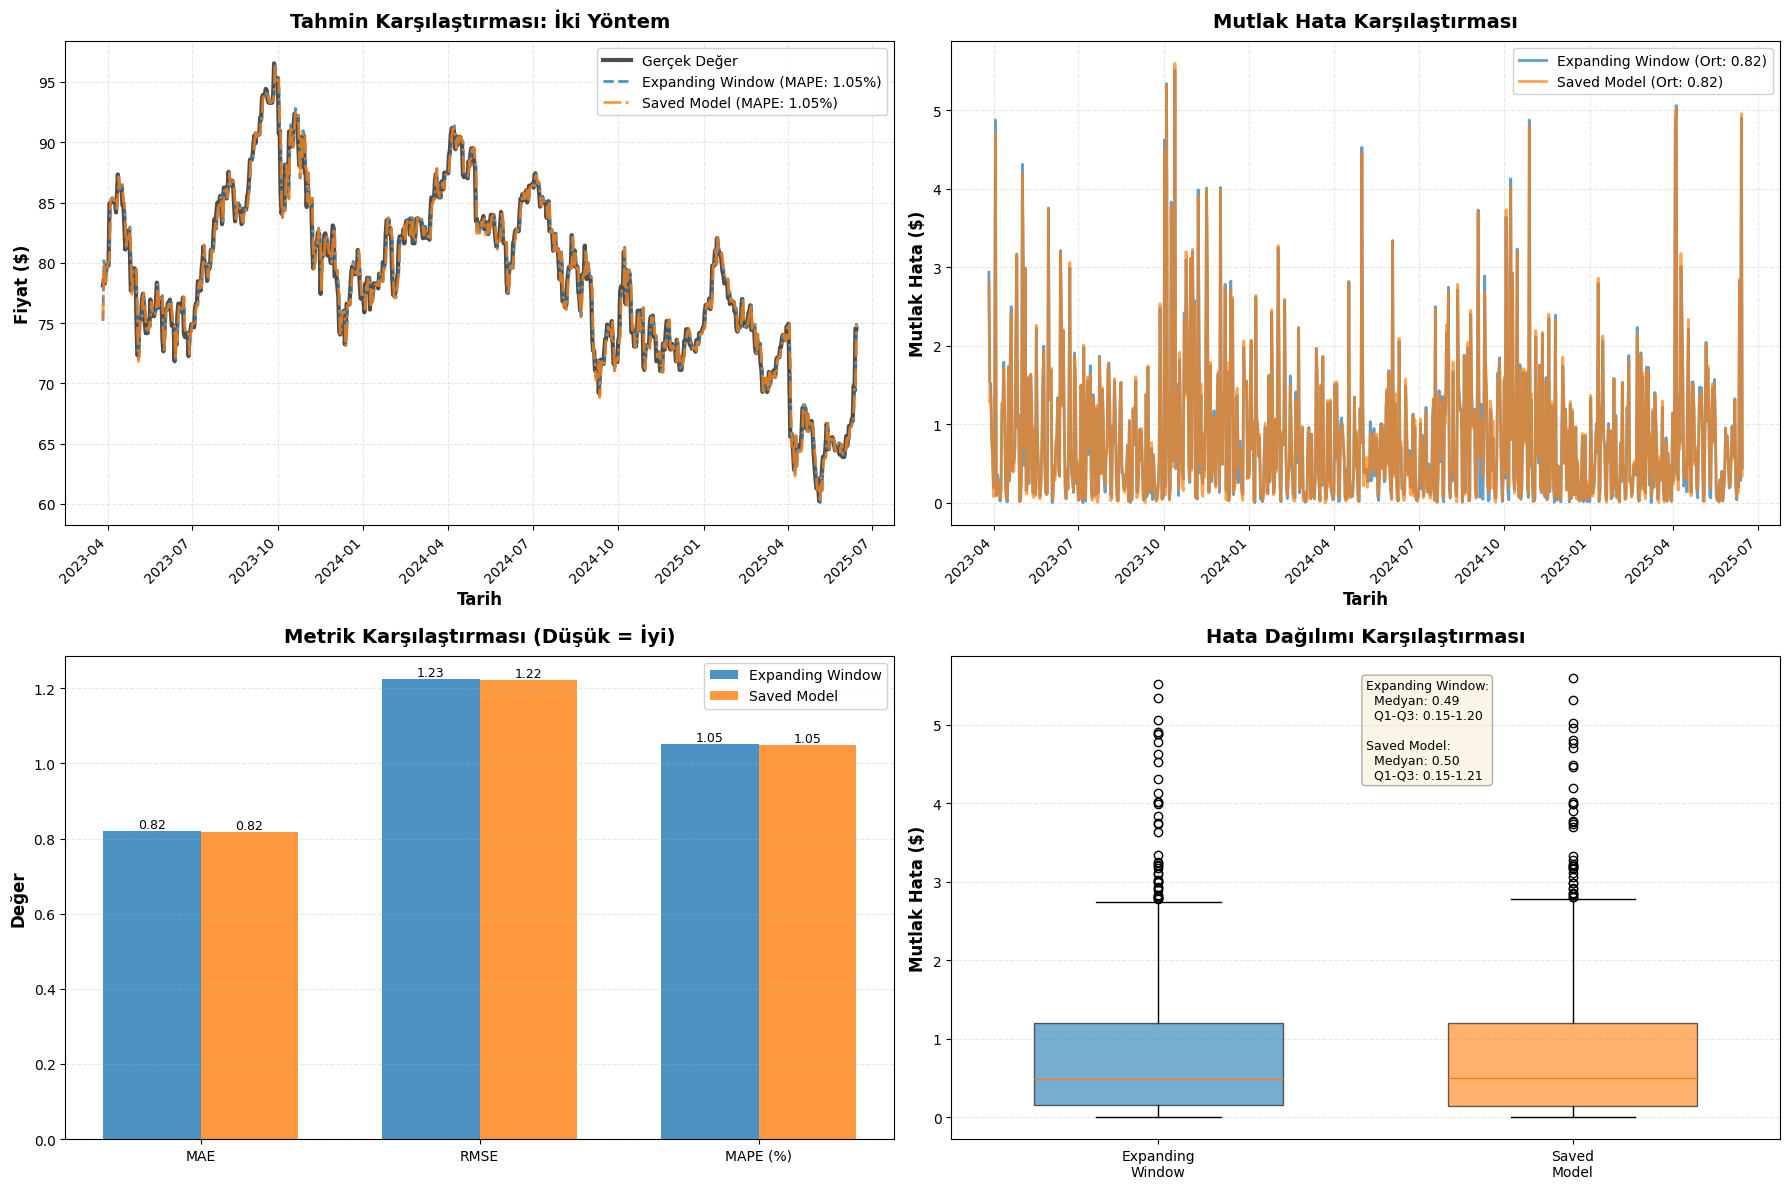


📊 DETAYLI İSTATİSTİKSEL KARŞILAŞTIRMA

Metrik                    Expanding Window     Saved Model          Fark           
----------------------------------------------------------------------
MAE ($)                   0.8194               0.8169               -0.0024 (-0.3%)
RMSE ($)                  1.2250               1.2216               -0.0035 (-0.3%)
MAPE (%)                  1.05                 1.05                 -0.00 (-0.3%)

----------------------------------------------------------------------
Medyan Hata ($)           0.4915               0.4961              
Max Hata ($)              5.5164               5.5970              
Min Hata ($)              0.0004               0.0003              
Std Sapma ($)             0.9113               0.9088              

🎯 ÖZET DEĞERLENDİRME:

✅ En iyi performans: Saved Model
   └─ 0.00% daha düşük MAPE

⚠️  Trade-off analizi:
   • Saved Model: Hem hızlı hem de 0.00% daha iyi!
   • Expanding Window: Yavaş ve daha az doğru

💡 Ön

In [33]:
# ADIM 4: İki yöntemi görsel olarak karşılaştır
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. TAHMİN KARŞILAŞTIRMASI: Gerçek vs İki Yöntem
ax1 = axes[0, 0]
ax1.plot(test_roll["ds"], test_roll["y_true"], 
         label="Gerçek Değer", color="black", linewidth=3, alpha=0.7)
ax1.plot(test_roll["ds"], test_roll["y_pred"], 
         label=f"Expanding Window (MAPE: {test_metrics['MAPE']:.2f}%)", 
         color="#1f77b4", linewidth=2, alpha=0.8, linestyle="--")
ax1.plot(test_roll_v2["ds"], test_roll_v2["y_pred"], 
         label=f"Saved Model (MAPE: {test_metrics_v2['MAPE']:.2f}%)", 
         color="#ff7f0e", linewidth=2, alpha=0.8, linestyle="-.")
ax1.set_xlabel("Tarih", fontsize=12, fontweight="bold")
ax1.set_ylabel("Fiyat ($)", fontsize=12, fontweight="bold")
ax1.set_title("Tahmin Karşılaştırması: İki Yöntem", fontsize=14, fontweight="bold", pad=10)
ax1.legend(fontsize=10, loc="best", framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle="--")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. MUTLAK HATA KARŞILAŞTIRMASI
ax2 = axes[0, 1]
ax2.plot(test_roll["ds"], test_roll["abs_err"], 
         label=f"Expanding Window (Ort: {test_roll['abs_err'].mean():.2f})", 
         color="#1f77b4", linewidth=2, alpha=0.7)
ax2.plot(test_roll_v2["ds"], test_roll_v2["abs_err"], 
         label=f"Saved Model (Ort: {test_roll_v2['abs_err'].mean():.2f})", 
         color="#ff7f0e", linewidth=2, alpha=0.7)
ax2.set_xlabel("Tarih", fontsize=12, fontweight="bold")
ax2.set_ylabel("Mutlak Hata ($)", fontsize=12, fontweight="bold")
ax2.set_title("Mutlak Hata Karşılaştırması", fontsize=14, fontweight="bold", pad=10)
ax2.legend(fontsize=10, loc="best", framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. METRİK KARŞILAŞTIRMA BAR CHART
ax3 = axes[1, 0]
metrics = ['MAE', 'RMSE', 'MAPE (%)']
expanding_vals = [test_metrics['MAE'], test_metrics['RMSE'], test_metrics['MAPE']]
saved_vals = [test_metrics_v2['MAE'], test_metrics_v2['RMSE'], test_metrics_v2['MAPE']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax3.bar(x - width/2, expanding_vals, width, label='Expanding Window', 
                color='#1f77b4', alpha=0.8)
bars2 = ax3.bar(x + width/2, saved_vals, width, label='Saved Model', 
                color='#ff7f0e', alpha=0.8)

# Değerleri barların üzerine yaz
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

ax3.set_ylabel('Değer', fontsize=12, fontweight="bold")
ax3.set_title('Metrik Karşılaştırması (Düşük = İyi)', fontsize=14, fontweight="bold", pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend(fontsize=10, framealpha=0.9)
ax3.grid(True, alpha=0.3, axis='y', linestyle="--")

# 4. HATA DAĞILIMI (BOX PLOT)
ax4 = axes[1, 1]
box_data = [test_roll["abs_err"], test_roll_v2["abs_err"]]
bp = ax4.boxplot(box_data, labels=['Expanding\nWindow', 'Saved\nModel'],
                  patch_artist=True, widths=0.6)

# Renklendirme
colors = ['#1f77b4', '#ff7f0e']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax4.set_ylabel('Mutlak Hata ($)', fontsize=12, fontweight="bold")
ax4.set_title('Hata Dağılımı Karşılaştırması', fontsize=14, fontweight="bold", pad=10)
ax4.grid(True, alpha=0.3, axis='y', linestyle="--")

# İstatistik bilgileri ekle
stats_text = (
    f"Expanding Window:\n"
    f"  Medyan: {test_roll['abs_err'].median():.2f}\n"
    f"  Q1-Q3: {test_roll['abs_err'].quantile(0.25):.2f}-{test_roll['abs_err'].quantile(0.75):.2f}\n\n"
    f"Saved Model:\n"
    f"  Medyan: {test_roll_v2['abs_err'].median():.2f}\n"
    f"  Q1-Q3: {test_roll_v2['abs_err'].quantile(0.25):.2f}-{test_roll_v2['abs_err'].quantile(0.75):.2f}"
)
ax4.text(1.5, ax4.get_ylim()[1]*0.95, stats_text, 
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# Detaylı istatistiksel karşılaştırma
print("\n" + "="*70)
print("📊 DETAYLI İSTATİSTİKSEL KARŞILAŞTIRMA")
print("="*70)

print(f"\n{'Metrik':<25} {'Expanding Window':<20} {'Saved Model':<20} {'Fark':<15}")
print("-" * 70)

mae_diff = test_metrics_v2['MAE'] - test_metrics['MAE']
mae_pct = (mae_diff / test_metrics['MAE']) * 100
print(f"{'MAE ($)':<25} {test_metrics['MAE']:<20.4f} {test_metrics_v2['MAE']:<20.4f} {mae_diff:>+.4f} ({mae_pct:>+.1f}%)")

rmse_diff = test_metrics_v2['RMSE'] - test_metrics['RMSE']
rmse_pct = (rmse_diff / test_metrics['RMSE']) * 100
print(f"{'RMSE ($)':<25} {test_metrics['RMSE']:<20.4f} {test_metrics_v2['RMSE']:<20.4f} {rmse_diff:>+.4f} ({rmse_pct:>+.1f}%)")

mape_diff = test_metrics_v2['MAPE'] - test_metrics['MAPE']
mape_pct = (mape_diff / test_metrics['MAPE']) * 100
print(f"{'MAPE (%)':<25} {test_metrics['MAPE']:<20.2f} {test_metrics_v2['MAPE']:<20.2f} {mape_diff:>+.2f} ({mape_pct:>+.1f}%)")

print("\n" + "-" * 70)
print(f"{'Medyan Hata ($)':<25} {test_roll['abs_err'].median():<20.4f} {test_roll_v2['abs_err'].median():<20.4f}")
print(f"{'Max Hata ($)':<25} {test_roll['abs_err'].max():<20.4f} {test_roll_v2['abs_err'].max():<20.4f}")
print(f"{'Min Hata ($)':<25} {test_roll['abs_err'].min():<20.4f} {test_roll_v2['abs_err'].min():<20.4f}")
print(f"{'Std Sapma ($)':<25} {test_roll['abs_err'].std():<20.4f} {test_roll_v2['abs_err'].std():<20.4f}")

print("\n" + "="*70)
print("🎯 ÖZET DEĞERLENDİRME:")
print("="*70)

# Hangi yöntem daha iyi?
if test_metrics['MAPE'] < test_metrics_v2['MAPE']:
    better = "Expanding Window"
    worse = "Saved Model"
    diff = test_metrics_v2['MAPE'] - test_metrics['MAPE']
else:
    better = "Saved Model"
    worse = "Expanding Window"
    diff = test_metrics['MAPE'] - test_metrics_v2['MAPE']

print(f"\n✅ En iyi performans: {better}")
print(f"   └─ {diff:.2f}% daha düşük MAPE")

print(f"\n⚠️  Trade-off analizi:")
if better == "Expanding Window":
    print(f"   • {better}: Daha doğru ama yavaş (her gün model eğitimi)")
    print(f"   • {worse}: Daha hızlı ama {diff:.2f}% daha fazla hata")
else:
    print(f"   • {better}: Hem hızlı hem de {diff:.2f}% daha iyi!")
    print(f"   • {worse}: Yavaş ve daha az doğru")

print("\n💡 Öneri:")
print(f"   • Akademik sunum için: Expanding Window (standart metodoloji)")
print(f"   • Production/Hız için: Saved Model (pratik ve hızlı)")
print("="*70)